In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [75]:
column_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df = pd.read_csv("iris.csv", header=None, names=column_names)
df

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [76]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['class']=le.fit_transform(df['class'])
df

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [77]:
X = df.drop('class', axis=1)
y = df['class']

In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [79]:
from sklearn.model_selection import train_test_split


X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 90
Validation set size: 30
Test set size: 30


In [80]:
model = Sequential([
    Input(shape=(X_train.shape[1]),name='input'),
    Dense(8, activation='relu',name='d1'),  # Hidden layer with 8 neurons
    Dense(4, activation='relu',name='d2'),  # Hidden layer with 4 neurons
    Dense(3, activation='softmax')
])

In [81]:
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 d1 (Dense)                  (None, 8)                 40        
                                                                 
 d2 (Dense)                  (None, 4)                 36        
                                                                 
 dense_6 (Dense)             (None, 3)                 15        
                                                                 
Total params: 91 (364.00 Byte)
Trainable params: 91 (364.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [82]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [83]:
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50,batch_size=32)

Epoch 1/50
3/3 [==============================] - 1s 113ms/step - loss: 0.9179 - accuracy: 0.5556 - val_loss: 0.5883 - val_accuracy: 0.7667
Epoch 2/50
3/3 [==============================] - 0s 18ms/step - loss: 0.4595 - accuracy: 0.8444 - val_loss: 0.3550 - val_accuracy: 0.8333
Epoch 3/50
3/3 [==============================] - 0s 18ms/step - loss: 0.3085 - accuracy: 0.8222 - val_loss: 0.2507 - val_accuracy: 0.9000
Epoch 4/50
3/3 [==============================] - 0s 17ms/step - loss: 0.2329 - accuracy: 0.8889 - val_loss: 0.2054 - val_accuracy: 0.9000
Epoch 5/50
3/3 [==============================] - 0s 20ms/step - loss: 0.1864 - accuracy: 0.9111 - val_loss: 0.1706 - val_accuracy: 0.9333
Epoch 6/50
3/3 [==============================] - 0s 18ms/step - loss: 0.1647 - accuracy: 0.9444 - val_loss: 0.1783 - val_accuracy: 0.9333
Epoch 7/50
3/3 [==============================] - 0s 17ms/step - loss: 0.0941 - accuracy: 0.9889 - val_loss: 0.1069 - val_accuracy: 0.9667
Epoch 8/50
3/3 [==========

In [84]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 [==============================] - 0s 28ms/step - loss: 0.2339 - accuracy: 0.9667
Test Loss: 0.23393754661083221
Test Accuracy: 0.9666666388511658


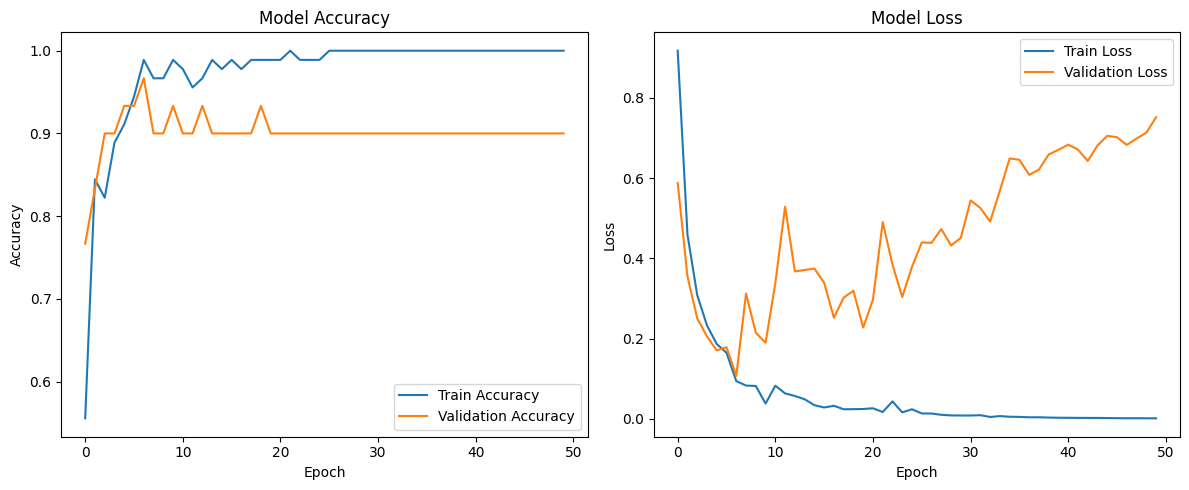

In [85]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()


##### inference:
- We can see this in a loss vs epoch graph. The training and validation losses decrease until an epoch, after which the validation grows while the training loss keeps dropping. 
- graph helps us understand the point at which overfitting happens. It’s the epoch after which the validation loss curve goes up.